In [ ]:
import pandas as pd
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine_data = pd.read_csv(url, sep=";")
wine_data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=wine_data)

MessageError: Error: credential propagation was unsuccessful

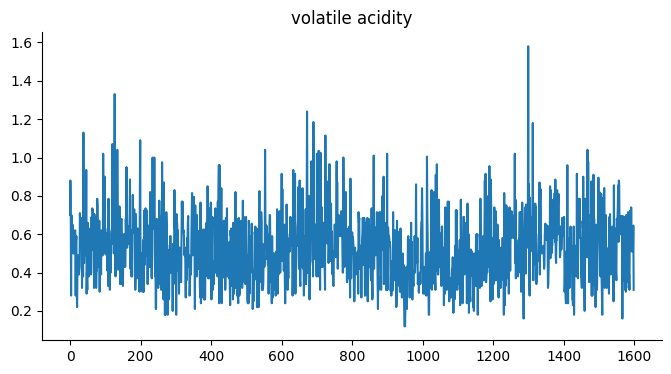

In [ ]:
# @title volatile acidity

from matplotlib import pyplot as plt
wine_data['volatile acidity'].plot(kind='line', figsize=(8, 4), title='volatile acidity')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
from sklearn.model_selection import train_test_split

X = wine_data.drop('quality', axis=1)
y = wine_data['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

**Accuracy of KNN without Feature Normalization**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: {:.2%}".format(accuracy))

Accuracy: 48.54%


**Accuracy of KNN with Feature Normalization -- Standarization**

In [ ]:
from sklearn.preprocessing import StandardScaler
# Create an instance of StandardScaler
scaler = StandardScaler()

X_train_standard = scaler.fit_transform(X_train)
X_test_standard = scaler.transform(X_test)

knn_standard = KNeighborsClassifier()
knn_standard.fit(X_train_standard, y_train)
y_pred_standard = knn_standard.predict(X_test_standard)
accuracy_standard = accuracy_score(y_test, y_pred_standard)
print("Accuracy with standarization: {:.2%}".format(accuracy_standard))

**Accuracy of KNN with Feature Normalization -- Min Max Scaler**

In [ ]:
from sklearn.preprocessing import MinMaxScaler # Import MinMaxScaler from sklearn.preprocessing

min_max_scaler = MinMaxScaler()
X_train_min_max = min_max_scaler.fit_transform(X_train)
X_test_min_max = min_max_scaler.transform(X_test)

knn_min_max = KNeighborsClassifier()
knn_min_max.fit(X_train_min_max, y_train)
y_pred_min_max = knn_min_max.predict(X_test_min_max)
accuracy_min_max = accuracy_score(y_test, y_pred_min_max)
print("Accuracy with min-max scaler: {:.2%}".format(accuracy_min_max))